# Underwater image enhancement (UIEB) with FUnIE-GAN

* **Model**: FUnIE-GAN of Islam, Xia & Sattar (RA-L 2020, arXiv:1903.09766), implemented **exactly as in the official PyTorch code** `xahidbuffon/FUnIE-GAN/PyTorch` (`nets/funiegan.py`, `nets/commons.py`, `train_funiegan.py`, `utils/data_utils.py`). The network classes in Section 1 are copied verbatim from the repo, so the generator `state_dict` is key-compatible with the repo's `funie_generator.pth` / `test.py`.
  * Generator: 5-level U-Net (32-128-256-256-256), 4x4 stride-2 convolutions, BatchNorm(momentum 0.8) + LeakyReLU(0.2) in the encoder, transposed convolutions + BatchNorm + ReLU in the decoder, final `Upsample -> ZeroPad -> Conv -> Tanh`.
  * Discriminator: conditional 4-block PatchGAN, input = (image, condition image) concatenated (6 channels), 16x16x1 patch map for a 256x256 image.
* **Training recipe (repo defaults)**: LSGAN (MSE) adversarial loss; generator loss = `L_GAN + 7 * L1 + 3 * L_SSIM` with `L_SSIM = 1 - SSIM` (the repo's VGG19 perceptual loss has been removed); discriminator loss = `0.5 * (real + fake) * 10`; one D step and one G step per batch; Adam with **separate learning rates** `LR_G` (generator) and `LR_D` (discriminator), both 3e-4 by default, betas 0.5 / 0.99; the generator LR is controlled by `ReduceLROnPlateau` (monitors validation PSNR, factor 0.5, patience 5, min LR 1e-6; same scheduler as the UGAN notebook), the discriminator LR stays constant; N(0, 0.02) weight init; images in [-1, 1]; bicubic resize to 256x256 + random horizontal flip only.
* **Training loop** (Section 4) is the notebook's own harness: after every epoch it prints the loss and all 4 metrics (PSNR, SSIM, LPIPS, UIQM) for train and validation, writes one CSV row, steps the LR scheduler on the validation PSNR, keeps **only the single best generator** (highest validation PSNR) and stops early after `PATIENCE` epochs without improvement. "Loss" is the generator loss (`L_GAN + 7*L1 + 3*(1 - SSIM)`); PSNR/SSIM/LPIPS/UIQM are computed on [0, 1] images.

Files written under `Dehaze/`:

| file | content |
|---|---|
| `logs/training_log.csv` | one row per epoch: LR (G and D), train loss + PSNR/SSIM/LPIPS/UIQM, val loss + PSNR/SSIM/LPIPS/UIQM, D loss, adversarial / L1 / SSIM loss terms, timings, throughput, GPU memory, `is_best` |
| `logs/metrics_test.csv` | final test metrics |
| `logs/timing_summary.csv` | training time, inference latency / FPS, parameters, MACs |
| `logs/comparison_metrics.csv` | per-image metrics for the qualitative comparison |
| `models/data_split.csv` | train/val/test file lists |
| `models/best_model_funiegan.pth` | best generator (`state_dict`, selected by validation PSNR; loadable by the repo's `test.py`) |
| `models/funiegan_final.pth` | generator weights + config after the test cell |

Reference: Islam, Xia & Sattar, "Fast Underwater Image Enhancement for Improved Visual Perception", IEEE RA-L 2020. Code: https://github.com/xahidbuffon/FUnIE-GAN

# Imports

In [1]:
# %pip install -q lpips thop scikit-image opencv-python scipy   # uncomment on a fresh environment
import sys
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
import time
import csv
import copy
import math
import random
import datetime
from pathlib import Path

from tqdm.auto import tqdm
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import lpips  # pip install lpips


e:\under_water_dehazing\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = os.path.abspath(".")
DATASET_ROOT = os.path.join(PROJECT_ROOT, "dataset")
RAW_DIR = os.path.join(DATASET_ROOT, "raw-890")          # degraded inputs
REF_DIR = os.path.join(DATASET_ROOT, "reference-890")    # clean reference images (same file names)
MODEL_SAVE_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "models")
LOG_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "logs")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "comparison_outputs")
for d in [MODEL_SAVE_DIR, LOG_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ---- data / optimisation  (FUnIE-GAN repo: PyTorch/train_funiegan.py defaults)
IMG_SIZE = 256
BATCH_SIZE = 8             # repo default
EPOCHS = 201               # repo default (--num_epochs); early stopping below may end the run sooner
LR_G = 3e-4                # generator initial learning rate (repo default --lr); reduced by the scheduler below
LR_D = 3e-4                # discriminator learning rate (repo default --lr), constant
ADAM_BETAS = (0.5, 0.99)   # repo defaults (--b1, --b2)
LR_PATIENCE = 5            # ReduceLROnPlateau on the generator, monitors validation PSNR (epochs without improvement before the LR is cut)
LR_FACTOR = 0.5            # LR_G <- LR_G * LR_FACTOR when the plateau is detected
LR_MIN = 1e-6              # lower bound of the generator LR

# ---- generator loss = adversarial (LSGAN) + LAMBDA_1 * L1 + LAMBDA_SSIM * (1 - SSIM)
LAMBDA_1 = 7.0             # weight of the L1 similarity loss (repo: lambda_1)
LAMBDA_SSIM = 3.0          # weight of the SSIM loss (1 - SSIM); takes the place of the removed perceptual-loss weight (repo: lambda_con = 3)
D_LOSS_SCALE = 10.0        # repo: loss_D = 0.5 * (loss_real + loss_fake) * 10.0   ("10x scaled for stability")

# ---- data split (UIEB has no official split)
VAL_FRACTION = 0.1
TEST_FRACTION = 0.1
TRAIN_UIQM = True                  # UIQM is a slow numpy metric; True = also computed on the train set every epoch
                                   # (False -> train UIQM is logged as NaN, val/test UIQM are always computed)

# ---- notebook training harness (best-model selection + early stopping; not part of the FUnIE-GAN repo)
PATIENCE = 25              # early stopping: stop after this many epochs without a new best val PSNR
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "best_model_funiegan.pth")   # the only model file written during training
USE_TORCH_COMPILE = True   # compiles the generator only (skipped automatically on Windows / without Triton)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- speed knobs -------------------------------------------------------
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True   # auto-tune conv algorithms (fixed input size)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.set_num_threads(4)  # cap CPU threads so workers don't fight each other

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# The generator halves H and W five times (skip connections need matching sizes) -> IMG_SIZE must be divisible by 32.
# The discriminator downsamples by 16 and outputs an (IMG_SIZE/16)^2 map of patch scores (16x16 for 256x256).
assert IMG_SIZE % 32 == 0, "IMG_SIZE must be divisible by 32"

for p in [RAW_DIR, REF_DIR]:
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Missing directory: {p}")

print(f"Device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
print("Raw images:", len(os.listdir(RAW_DIR)), "Reference images:", len(os.listdir(REF_DIR)))
print(f"FUnIE-GAN | lr_G={LR_G} (ReduceLROnPlateau x{LR_FACTOR}, patience {LR_PATIENCE}, min {LR_MIN:g}) lr_D={LR_D} betas={ADAM_BETAS} batch={BATCH_SIZE} | loss_G = L_GAN + {LAMBDA_1:g}*L1 + {LAMBDA_SSIM:g}*(1-SSIM) | loss_D = 0.5*(real+fake)*{D_LOSS_SCALE:g}")


Device: cuda (NVIDIA GeForce RTX 3060)
Raw images: 890 Reference images: 890
FUnIE-GAN | lr_G=0.0003 (ReduceLROnPlateau x0.5, patience 5, min 1e-06) lr_D=0.0003 betas=(0.5, 0.99) batch=8 | loss_G = L_GAN + 7*L1 + 3*(1-SSIM) | loss_D = 0.5*(real+fake)*10


## Dataset Loader

In [3]:
# ============================================================================
# Helper utilities  (np_to_tensor, tensor_to_uint8, compute_uiqm,
#                    ssim_torch, sync, lpips_fn)
# ============================================================================
import torch, numpy as np
import lpips as _lpips_module

# ---------- tensor <-> numpy helpers ----------------------------------------

def np_to_tensor(img_uint8):
    """uint8 HxWx3 numpy array -> float32 3xHxW tensor in [0,1]."""
    return torch.from_numpy(img_uint8.astype(np.float32) / 255.0).permute(2, 0, 1)


def tensor_to_uint8(t):
    """3xHxW (or 1x3xHxW) float tensor in [0,1] -> uint8 HxWx3 numpy array."""
    if t.dim() == 4:
        t = t.squeeze(0)
    return (t.detach().clamp(0, 1).permute(1, 2, 0).cpu().float().numpy() * 255.0).round().astype(np.uint8)


# ---------- CUDA sync helper ------------------------------------------------

def sync():
    """Block until all CUDA kernels complete (no-op on CPU)."""
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


# ---------- SSIM (differentiable, batched) ----------------------------------

def _gaussian_kernel_1d(size=11, sigma=1.5):
    x = torch.arange(size, dtype=torch.float32) - size // 2
    k = torch.exp(-x ** 2 / (2 * sigma ** 2))
    return k / k.sum()


def _ssim_kernel(size=11, sigma=1.5):
    k1d = _gaussian_kernel_1d(size, sigma)
    k2d = k1d.unsqueeze(1) * k1d.unsqueeze(0)        # (size, size)
    return k2d.unsqueeze(0).unsqueeze(0)              # (1, 1, size, size)


_SSIM_WIN = None        # cached kernel (keyed by device + dtype)
_SSIM_WIN_KEY = None


def ssim_torch(pred, target, size=11, sigma=1.5, C1=0.01**2, C2=0.03**2):
    """Per-image differentiable SSIM.  Returns shape (B,).
    Always computed in float32: the model output can be float16 (AMP) while the target is float32, and
    variance = E[x^2] - E[x]^2 is numerically unreliable in float16."""
    global _SSIM_WIN, _SSIM_WIN_KEY
    pred, target = pred.float(), target.float()
    key = (pred.device, torch.float32)
    if _SSIM_WIN is None or _SSIM_WIN_KEY != key:
        _SSIM_WIN = _ssim_kernel(size, sigma).to(pred.device, dtype=torch.float32)
        _SSIM_WIN_KEY = key
    B, C, H, W = pred.shape
    # Treat all channels independently then average
    p = pred.reshape(B * C, 1, H, W)
    t = target.reshape(B * C, 1, H, W)
    pad = size // 2
    mu_p  = torch.nn.functional.conv2d(p, _SSIM_WIN, padding=pad)
    mu_t  = torch.nn.functional.conv2d(t, _SSIM_WIN, padding=pad)
    mu_p2 = mu_p ** 2
    mu_t2 = mu_t ** 2
    mu_pt = mu_p * mu_t
    sig_p2 = torch.nn.functional.conv2d(p * p, _SSIM_WIN, padding=pad) - mu_p2
    sig_t2 = torch.nn.functional.conv2d(t * t, _SSIM_WIN, padding=pad) - mu_t2
    sig_pt = torch.nn.functional.conv2d(p * t, _SSIM_WIN, padding=pad) - mu_pt
    num = (2 * mu_pt + C1) * (2 * sig_pt + C2)
    den = (mu_p2 + mu_t2 + C1) * (sig_p2 + sig_t2 + C2)
    ssim_map = num / den.clamp_min(1e-8)
    ssim_per_channel = ssim_map.reshape(B, C, H, W).mean(dim=(1, 2, 3))   # (B,)
    return ssim_per_channel


# ---------- LPIPS (evaluation metric only -- not part of the loss) -----------------------------

lpips_fn = _lpips_module.LPIPS(net="alex", verbose=False).to(DEVICE)


# ---------- UIQM (Underwater Image Quality Measure) ------------------------
# Ref: Panetta et al. 2016.  Pure-numpy implementation, runs on CPU.
# Same implementation as in the WaterNet notebook, so the UIQM numbers of the two models are comparable.

def _uicm(img_f32):
    """Chroma measure."""
    rg = img_f32[:, :, 0] - img_f32[:, :, 1]
    yb = 0.5 * (img_f32[:, :, 0] + img_f32[:, :, 1]) - img_f32[:, :, 2]
    def _stats(x):
        mu = x.mean(); sigma = x.std()
        # asymmetric alpha-trimmed mean
        flat = x.flatten(); flat.sort()
        n = len(flat); lo, hi = int(0.1 * n), int(0.9 * n)
        alpha_mu = flat[lo:hi].mean() if hi > lo else mu
        return alpha_mu, sigma
    mu_rg, sig_rg = _stats(rg)
    mu_yb, sig_yb = _stats(yb)
    return -0.0268 * np.sqrt(mu_rg**2 + mu_yb**2) + 0.1586 * np.sqrt(sig_rg**2 + sig_yb**2)


def _uism(img_uint8):
    """Sharpness measure (Sobel)."""
    from scipy import ndimage
    score = 0.0
    weights = [0.299, 0.587, 0.114]
    for ch, w in enumerate(weights):
        chan = img_uint8[:, :, ch].astype(np.float32)
        sx = ndimage.sobel(chan, axis=0); sy = ndimage.sobel(chan, axis=1)
        edges = np.hypot(sx, sy)
        # EME (Enhancement Measure Estimation) with k=8 blocks
        h, wd = edges.shape
        bh, bw = max(h // 8, 1), max(wd // 8, 1)
        eme = 0.0; count = 0
        for r in range(0, h, bh):
            for c in range(0, wd, bw):
                blk = edges[r:r+bh, c:c+bw]
                mx = blk.max(); mn = blk.min()
                if mx > 0 and mn > 0:
                    eme += np.log(mx / (mn + 1e-5))
                    count += 1
        score += w * (2.0 / max(count, 1)) * eme
    return score


def _uiconm(img_f32):
    """Contrast measure."""
    from scipy import ndimage
    gray = 0.299 * img_f32[:, :, 0] + 0.587 * img_f32[:, :, 1] + 0.114 * img_f32[:, :, 2]
    ambe = np.abs(ndimage.uniform_filter(gray, size=8) - gray.mean())
    return np.log1p(ambe.mean())


def compute_uiqm(img_uint8):
    """UIQM score for a uint8 HxWx3 numpy array."""
    img_f32 = img_uint8.astype(np.float32) / 255.0
    c1, c2, c3 = 0.0282, 0.2953, 3.5753
    return c1 * _uicm(img_f32) + c2 * _uism(img_uint8) + c3 * _uiconm(img_f32)

print("Helper utilities ready  (ssim_torch, lpips_fn, sync, np_to_tensor, tensor_to_uint8)")

e:\under_water_dehazing\myenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\under_water_dehazing\myenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Helper utilities ready  (ssim_torch, lpips_fn, sync, np_to_tensor, tensor_to_uint8)


In [4]:
_BICUBIC = Image.Resampling.BICUBIC if hasattr(Image, "Resampling") else Image.BICUBIC


def load_rgb_resized(path, size):
    """uint8 HxWx3 array. Same as the repo's  transforms.Resize((H, W), Image.BICUBIC)  applied to the PIL image."""
    with Image.open(path) as im:
        return np.array(im.convert("RGB").resize((size, size), _BICUBIC))


class UIEBDataset(Dataset):
    """Returns (degraded image I, reference image J), both 3xHxW float32 in [0,1].
    (The repo feeds the networks [-1,1] images = ToTensor + Normalize(0.5, 0.5); that conversion is done on the GPU in
    the training / evaluation code, so the metrics keep working on [0,1] images.)
    Augmentation = the repo's GetTrainingPairs: random horizontal flip (p = 0.5) applied to BOTH images, nothing else."""
    def __init__(self, pairs, img_size=256, train=False, cache_in_memory=True):
        self.pairs = pairs
        self.img_size = img_size
        self.train = train
        self.cache_in_memory = cache_in_memory
        if self.cache_in_memory:
            # Pre-load & resize into contiguous uint8 arrays -> eliminates disk I/O per batch
            self.cached_pairs = [
                (self._load(raw_p), self._load(ref_p)) for raw_p, ref_p in pairs
            ]

    def __len__(self):
        return len(self.pairs)

    def _load(self, path):
        return load_rgb_resized(path, self.img_size)

    def _augment(self, raw, ref):
        if random.random() < 0.5:                                     # repo: np.random.random() < 0.5 -> flip along width
            raw, ref = np.fliplr(raw).copy(), np.fliplr(ref).copy()
        return raw, ref

    def __getitem__(self, idx):
        if self.cache_in_memory:
            raw, ref = self.cached_pairs[idx]
            raw, ref = raw.copy(), ref.copy()
        else:
            raw_path, ref_path = self.pairs[idx]
            raw, ref = self._load(raw_path), self._load(ref_path)
        if self.train:
            raw, ref = self._augment(raw, ref)
        return np_to_tensor(raw), np_to_tensor(ref)


# 1. Base Model

FUnIE-GAN (generator + conditional PatchGAN discriminator) and the weight initialisation, **copied verbatim** from `PyTorch/nets/funiegan.py` and `PyTorch/nets/commons.py` of https://github.com/xahidbuffon/FUnIE-GAN. The repo's VGG19 perceptual loss has been removed; it is replaced by an SSIM loss (see Section 2). The networks work on images in [-1, 1] (tanh output); `enhance()` wraps the generator so that the rest of the notebook only sees images in [0, 1].

In [5]:
# ======================= FUnIE-GAN (Islam, Xia & Sattar, arXiv:1903.09766) =======================
# Source: https://github.com/xahidbuffon/FUnIE-GAN  (PyTorch/nets/funiegan.py, PyTorch/nets/commons.py)

class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, bn=True):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1, bias=False)]
        if bn: layers.append(nn.BatchNorm2d(out_size, momentum=0.8))
        layers.append(nn.LeakyReLU(0.2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_size, out_size):
        super(UNetUp, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_size, momentum=0.8),
            nn.ReLU(inplace=True),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x


class GeneratorFunieGAN(nn.Module):
    """ A 5-layer UNet-based generator as described in the paper
    """
    def __init__(self, in_channels=3, out_channels=3):
        super(GeneratorFunieGAN, self).__init__()
        # encoding layers
        self.down1 = UNetDown(in_channels, 32, bn=False)
        self.down2 = UNetDown(32, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 256)
        self.down5 = UNetDown(256, 256, bn=False)
        # decoding layers
        self.up1 = UNetUp(256, 256)
        self.up2 = UNetUp(512, 256)
        self.up3 = UNetUp(512, 128)
        self.up4 = UNetUp(256, 32)
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(64, out_channels, 4, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        u1 = self.up1(d5, d4)
        u2 = self.up2(u1, d3)
        u3 = self.up3(u2, d2)
        u45 = self.up4(u3, d1)
        return self.final(u45)


class DiscriminatorFunieGAN(nn.Module):
    """ A 4-layer Markovian discriminator as described in the paper
    """
    def __init__(self, in_channels=3):
        super(DiscriminatorFunieGAN, self).__init__()

        def discriminator_block(in_filters, out_filters, bn=True):
            #Returns downsampling layers of each discriminator block
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if bn: layers.append(nn.BatchNorm2d(out_filters, momentum=0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels*2, 32, bn=False),
            *discriminator_block(32, 64),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(256, 1, 4, padding=1, bias=False)
        )

    def forward(self, img_A, img_B):
        # Concatenate image and condition image by channels to produce input
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)


def Weights_Normal(m):
    # initialize weights as Normal(mean, std)
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm2d") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)


In [6]:
generator = GeneratorFunieGAN().to(DEVICE)
discriminator = DiscriminatorFunieGAN().to(DEVICE)
generator.apply(Weights_Normal)          # repo: weights are initialised with N(0, 0.02) when training from scratch
discriminator.apply(Weights_Normal)


def count_params(*modules):
    return sum(p.numel() for m in modules if m is not None for p in m.parameters())


def enhance(I):
    """Batch of degraded images in [0, 1] -> FUnIE-GAN generator (works on [-1, 1]) -> enhanced images in [0, 1]."""
    return (generator(I * 2.0 - 1.0) + 1.0) / 2.0


class DehazePipeline(nn.Module):
    """Wrapper used only for MAC counting (takes / returns images in [0, 1])."""
    def __init__(self, gen):
        super().__init__()
        self.gen = gen

    def forward(self, I):
        return (self.gen(I * 2.0 - 1.0) + 1.0) / 2.0


# shape sanity check: the output must have the same H x W as the input; D outputs a (H/16, W/16) patch map
generator.eval(); discriminator.eval()
with torch.no_grad():
    _x = torch.rand(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    _y = enhance(_x)
    _d = discriminator(_x * 2.0 - 1.0, _x * 2.0 - 1.0)
assert _y.shape == (1, 3, IMG_SIZE, IMG_SIZE), f"unexpected generator output shape {tuple(_y.shape)}"
assert 0.0 <= _y.min().item() and _y.max().item() <= 1.0, "FUnIE-GAN ends with a tanh -> enhance() output must be in [0,1]"
assert _d.shape == (1, 1, IMG_SIZE // 16, IMG_SIZE // 16), f"unexpected discriminator output shape {tuple(_d.shape)}"
del _x, _y, _d
print(f"FUnIE-GAN generator parameters: {count_params(generator) / 1e6:.2f} M | discriminator parameters: {count_params(discriminator) / 1e6:.2f} M | output shapes OK")


FUnIE-GAN generator parameters: 7.02 M | discriminator parameters: 0.70 M | output shapes OK


# 2.Losses, Optimizers, and Metrics

In [7]:
class DehazeMetrics:
    """Accumulates PSNR / SSIM / LPIPS (/ UIQM) over batches. Predictions are quantised to 8 bit first so that
    validation, test and the qualitative comparison (uint8 PNGs) all measure the same thing."""
    def __init__(self, compute_uiqm_flag=False, compute_lpips_flag=False):
        self.compute_uiqm_flag = compute_uiqm_flag
        self.compute_lpips_flag = compute_lpips_flag
        self.sums = {"psnr": 0.0, "ssim": 0.0, "lpips": 0.0, "uiqm": 0.0}
        self.n = 0

    def update(self, pred, target):
        # dtype fix: pred may be float16 (AMP). Quantising in float16 is inexact, and mixing float16/float32
        # in SSIM / LPIPS raises a dtype error -> do every metric in float32.
        pred, target = pred.detach().float(), target.detach().float()
        pred_q = torch.round(pred.clamp(0, 1) * 255.0) / 255.0
        mse = ((pred_q - target) ** 2).mean(dim=(1, 2, 3)).clamp_min(1e-10)
        self.sums["psnr"] += (10.0 * torch.log10(1.0 / mse)).sum().item()
        self.sums["ssim"] += ssim_torch(pred_q, target).sum().item()
        if self.compute_lpips_flag:
            self.sums["lpips"] += lpips_fn(pred_q, target, normalize=True).sum().item()
        if self.compute_uiqm_flag:
            for img in pred_q:
                self.sums["uiqm"] += compute_uiqm(tensor_to_uint8(img))
        self.n += pred.size(0)

    def compute(self):
        n = max(self.n, 1)
        out = {k: v / n for k, v in self.sums.items()}
        if not self.compute_uiqm_flag:
            out["uiqm"] = float("nan")
        if not self.compute_lpips_flag:
            out["lpips"] = float("nan")
        return out


# ------------------------------------------------------------------ losses:  L_G = L_adv + LAMBDA_1 * L1 + LAMBDA_SSIM * (1 - SSIM)
Adv_cGAN = nn.MSELoss()                    # LSGAN adversarial loss
L1_G = nn.L1Loss()                         # similarity loss (L1), computed on [-1, 1] images like in the repo


def ssim_loss(imgs_fake, imgs_gt):
    """1 - mean SSIM. The networks work on [-1, 1] images, SSIM (C1, C2 constants) assumes [0, 1] -> convert first."""
    return 1.0 - ssim_torch((imgs_fake + 1.0) / 2.0, (imgs_gt + 1.0) / 2.0).mean()


def generator_loss(imgs_fake, imgs_gt, pred_fake):
    """loss_G = loss_GAN + lambda_1 * loss_1 + lambda_ssim * loss_ssim.
    pred_fake = D(imgs_fake, condition) -> the generator wants it to look 'valid' (all ones)."""
    loss_GAN = Adv_cGAN(pred_fake, torch.ones_like(pred_fake))
    loss_1 = L1_G(imgs_fake, imgs_gt)
    loss_ssim = ssim_loss(imgs_fake, imgs_gt)
    loss_G = loss_GAN + LAMBDA_1 * loss_1 + LAMBDA_SSIM * loss_ssim
    return loss_G, loss_GAN, loss_1, loss_ssim


# ------------------------------------------------------------------ optimisers (Adam, separate learning rates for G and D, fp32) + generator LR scheduler
optimizer_G = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=ADAM_BETAS)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=ADAM_BETAS)
scheduler_G = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_G, mode="max", factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=LR_MIN      # monitors val PSNR (higher = better); D keeps a constant LR
)


# 3. Dataloader

In [8]:
def collect_pairs(raw_dir, ref_dir):
    """Return sorted list of (raw_path, ref_path) tuples for files present in both dirs."""
    raw_files = {p.name: p for p in Path(raw_dir).iterdir() if p.is_file()}
    ref_files = {p.name: p for p in Path(ref_dir).iterdir() if p.is_file()}
    common = sorted(raw_files.keys() & ref_files.keys())
    return [(raw_files[n], ref_files[n]) for n in common]


def split_pairs(pairs, val_fraction, test_fraction, seed):
    """Randomly split pairs into train / val / test lists."""
    rng = random.Random(seed)
    shuffled = list(pairs)
    rng.shuffle(shuffled)
    n = len(shuffled)
    n_test = max(1, int(n * test_fraction))
    n_val  = max(1, int(n * val_fraction))
    test  = shuffled[:n_test]
    val   = shuffled[n_test:n_test + n_val]
    train = shuffled[n_test + n_val:]
    return train, val, test


num_workers = 0   # parallel data workers; set to 0 if you see multiprocessing errors

all_pairs = collect_pairs(RAW_DIR, REF_DIR)
if len(all_pairs) == 0:
    raise RuntimeError(f"No raw/reference pairs found in {RAW_DIR} and {REF_DIR}")
train_pairs, val_pairs, test_pairs = split_pairs(all_pairs, VAL_FRACTION, TEST_FRACTION, SEED)

# Save the split so results are reproducible / reportable
with open(os.path.join(MODEL_SAVE_DIR, "data_split.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "file"])
    for name, pairs in [("train", train_pairs), ("val", val_pairs), ("test", test_pairs)]:
        for raw_p, _ in pairs:
            w.writerow([name, raw_p.name])

train_dataset = UIEBDataset(train_pairs, IMG_SIZE, train=True)
val_dataset = UIEBDataset(val_pairs, IMG_SIZE, train=False)
test_dataset = UIEBDataset(test_pairs, IMG_SIZE, train=False)

_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                  persistent_workers=num_workers > 0,
                  prefetch_factor=2 if num_workers > 0 else None)
train_loader = DataLoader(train_dataset, shuffle=True,                      # repo: shuffle=True, no drop_last
                          generator=torch.Generator().manual_seed(SEED), **_loader_kw)
val_loader = DataLoader(val_dataset, shuffle=False, **_loader_kw)
test_loader = DataLoader(test_dataset, shuffle=False, **_loader_kw)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 712
Val samples: 89
Test samples: 89


In [9]:
def format_metrics(prefix, metrics):
    return (
        f"{prefix} psnr={metrics['psnr']:.3f} ssim={metrics['ssim']:.4f} "
        f"lpips={metrics['lpips']:.4f} uiqm={metrics['uiqm']:.3f}"
    )


def print_metric_block(title, res):
    """Loss + the 4 metrics, one per line (same layout as ASRD_U_Mamba.ipynb)."""
    print(f"\n{title}")
    print("-" * 60)
    print(f"Loss       : {res['loss']:.4f}")
    print(f"PSNR (dB)  : {res['psnr']:.3f}")
    print(f"SSIM       : {res['ssim']:.4f}")
    print(f"LPIPS      : {res['lpips']:.4f}")
    print(f"UIQM       : {res['uiqm']:.3f}")


def train_one_epoch(loader, epoch=None, total_epochs=None):
    """One FUnIE-GAN epoch, exactly the repo's per-batch procedure:
         1. discriminator step:  loss_D = 0.5 * (MSE(D(gt, x), 1) + MSE(D(G(x), x), 0)) * 10
         2. generator step:      loss_G = MSE(D(G(x), x), 1) + 7 * L1(G(x), gt) + 3 * (1 - SSIM(G(x), gt))
       (the generator is run twice per batch, as in the repo; in step 1 its output is only used as a constant, so it is
       computed without autograd.)  Everything is float32 (the repo does not use AMP).
       Returns mean loss (= loss_G) + PSNR/SSIM/LPIPS/UIQM + GAN statistics + timing."""
    generator.train()
    discriminator.train()
    metrics = DehazeMetrics(compute_uiqm_flag=TRAIN_UIQM, compute_lpips_flag=True)
    sums = {"loss": 0.0, "loss_D": 0.0, "loss_adv": 0.0, "loss_l1": 0.0, "loss_ssim": 0.0}
    n, data_time = 0, 0.0
    sync()
    t_start = t_prev = time.perf_counter()
    desc = f"Epoch {epoch}/{total_epochs} [Train]" if (epoch and total_epochs) else "Training"
    pbar = tqdm(loader, desc=desc, leave=False)
    for I, J in pbar:
        data_time += time.perf_counter() - t_prev
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)
        imgs_distorted = I * 2.0 - 1.0                     # repo: Normalize((0.5,)*3, (0.5,)*3)  ->  [-1, 1]
        imgs_good_gt = J * 2.0 - 1.0

        # ---- Train Discriminator
        optimizer_D.zero_grad(set_to_none=True)
        with torch.no_grad():
            imgs_fake = generator(imgs_distorted)
        pred_real = discriminator(imgs_good_gt, imgs_distorted)
        loss_real = Adv_cGAN(pred_real, torch.ones_like(pred_real))
        pred_fake = discriminator(imgs_fake, imgs_distorted)
        loss_fake = Adv_cGAN(pred_fake, torch.zeros_like(pred_fake))
        loss_D = 0.5 * (loss_real + loss_fake) * D_LOSS_SCALE      # 10x scaled for stability (repo)
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator
        optimizer_G.zero_grad(set_to_none=True)
        imgs_fake = generator(imgs_distorted)
        pred_fake = discriminator(imgs_fake, imgs_distorted)
        loss_G, loss_GAN, loss_1, loss_ssim = generator_loss(imgs_fake, imgs_good_gt, pred_fake)
        loss_G.backward()
        optimizer_G.step()

        bs = I.size(0)
        for k, v in (("loss", loss_G), ("loss_D", loss_D), ("loss_adv", loss_GAN), ("loss_l1", loss_1), ("loss_ssim", loss_ssim)):
            sums[k] += v.item() * bs
        n += bs
        with torch.no_grad():
            metrics.update(((imgs_fake.detach() + 1.0) / 2.0), J)
        pbar.set_postfix(loss=f"{loss_G.item():.4f}", D=f"{loss_D.item():.3f}", l1=f"{loss_1.item():.4f}", ssim_l=f"{loss_ssim.item():.4f}")
        t_prev = time.perf_counter()
    sync()
    elapsed = time.perf_counter() - t_start
    out = {k: v / max(n, 1) for k, v in sums.items()}
    out.update(metrics.compute())
    out.update(time_s=elapsed, data_time_s=data_time, imgs_per_s=n / max(elapsed, 1e-9))
    return out


@torch.no_grad()
def evaluate(loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc="Val"):
    """Returns a dict: generator loss (L_GAN + 7*L1 + 3*(1-SSIM), discriminator in eval mode), l1 (on [-1,1] images),
    psnr, ssim, lpips, uiqm, time_s (all 4 metrics on by default)."""
    generator.eval()
    discriminator.eval()
    metrics = DehazeMetrics(compute_uiqm_flag=compute_uiqm_flag, compute_lpips_flag=compute_lpips_flag)
    sums = {"loss": 0.0, "l1": 0.0, "ssim_loss": 0.0, "adv": 0.0}   # "ssim_loss" = 1 - SSIM (the "ssim" key is the metric)
    n = 0
    sync()
    t_start = time.perf_counter()
    pbar = tqdm(loader, desc=f"Evaluating [{desc}]", leave=False)
    for I, J in pbar:
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)
        x, y = I * 2.0 - 1.0, J * 2.0 - 1.0
        imgs_fake = generator(x)
        pred_fake = discriminator(imgs_fake, x)
        loss_G, loss_GAN, loss_1, loss_ssim = generator_loss(imgs_fake, y, pred_fake)
        pred = (imgs_fake + 1.0) / 2.0
        bs = I.size(0)
        for k, v in (("loss", loss_G), ("l1", loss_1), ("ssim_loss", loss_ssim), ("adv", loss_GAN)):
            sums[k] += v.item() * bs
        n += bs
        metrics.update(pred, J)
        pbar.set_postfix(loss=f"{loss_G.item():.4f}", l1=f"{loss_1.item():.4f}")
    sync()
    res = {k: v / max(n, 1) for k, v in sums.items()}
    res.update(metrics.compute())
    res["time_s"] = time.perf_counter() - t_start
    return res


# 4.Training Loop

In [10]:
best_model_path = BEST_MODEL_PATH
train_log_path = os.path.join(LOG_DIR, "training_log.csv")

LOG_FIELDS = (
    ["epoch", "timestamp", "lr_G", "lr_D"]
    + [f"train_{k}" for k in ("loss", "psnr", "ssim", "lpips", "uiqm")]
    + [f"val_{k}" for k in ("loss", "psnr", "ssim", "lpips", "uiqm")]
    + ["train_loss_D", "train_loss_adv", "train_loss_l1", "train_loss_ssim",
       "train_time_s", "data_time_s", "val_time_s", "epoch_time_s", "cumulative_time_s",
       "train_imgs_per_s", "gpu_peak_mem_mb", "is_best"]
)


def save_atomic(obj, path):
    """Write to a temp file, then rename -> a crash mid-save can never leave a corrupt model file."""
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


# ---- torch.compile (generator only): not supported on Windows (requires Triton) ----
raw_generator = getattr(generator, "_orig_mod", generator)     # un-compiled module: its state_dict has clean key names
if USE_TORCH_COMPILE and hasattr(torch, "compile") and sys.platform != "win32":
    try:
        generator = torch.compile(raw_generator)               # compile the raw module, so re-running this cell is safe
        print("torch.compile() enabled for the generator", flush=True)
    except Exception as e:
        print(f"torch.compile() skipped: {e}", flush=True)
else:
    print("torch.compile() skipped (disabled / Windows / Triton not available) -- other optimisations still active", flush=True)

best_val_psnr, best_epoch, counter, cum_time = -float("inf"), 0, 0, 0.0

train_start = time.time()
print("Training start:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_start)), flush=True)

with open(train_log_path, "w", newline="") as log_file:
    writer = csv.DictWriter(log_file, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for epoch in range(EPOCHS):
        print("\n" + "=" * 80)
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print("=" * 80, flush=True)

        if DEVICE.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
        sync()
        epoch_start = time.perf_counter()
        lr_G_used = optimizer_G.param_groups[0]["lr"]
        lr_D_used = optimizer_D.param_groups[0]["lr"]

        # ------------------ Training & Validation ------------------
        tr = train_one_epoch(train_loader, epoch=epoch + 1, total_epochs=EPOCHS)
        va = evaluate(val_loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc=f"Epoch {epoch + 1}/{EPOCHS} Val")
        scheduler_G.step(va["psnr"])        # reduce the generator LR when validation PSNR plateaus (lr_G_used above = LR used during this epoch)

        sync()
        epoch_time = time.perf_counter() - epoch_start
        cum_time += epoch_time
        peak_mem = torch.cuda.max_memory_allocated() / 2 ** 20 if DEVICE.type == "cuda" else 0.0

        # ------------------ CHECKPOINT: best generator only (highest validation PSNR; GAN losses are not comparable across epochs) ------------------
        is_best = va["psnr"] > best_val_psnr
        if is_best:
            best_val_psnr, best_epoch, counter = float(va["psnr"]), epoch + 1, 0
            save_atomic(raw_generator.state_dict(), best_model_path)
        else:
            counter += 1

        # ------------------ CSV log (flushed every epoch, so it survives a crash) ------------------
        row = {"epoch": epoch + 1, "timestamp": datetime.datetime.now().isoformat(timespec="seconds"), "lr_G": lr_G_used, "lr_D": lr_D_used}
        row.update({f"train_{k}": tr[k] for k in ("loss", "psnr", "ssim", "lpips", "uiqm")})
        row.update({f"val_{k}": va[k] for k in ("loss", "psnr", "ssim", "lpips", "uiqm")})
        row.update(train_loss_D=tr["loss_D"], train_loss_adv=tr["loss_adv"], train_loss_l1=tr["loss_l1"], train_loss_ssim=tr["loss_ssim"],
                   train_time_s=tr["time_s"], data_time_s=tr["data_time_s"], val_time_s=va["time_s"],
                   epoch_time_s=epoch_time, cumulative_time_s=cum_time,
                   train_imgs_per_s=tr["imgs_per_s"], gpu_peak_mem_mb=peak_mem, is_best=int(is_best))
        writer.writerow(row)
        log_file.flush()

        # ------------------ console: loss + 4 metrics, train and validation ------------------
        print_metric_block("TRAIN METRICS", tr)
        print_metric_block("VALIDATION METRICS", va)
        print("\nTRAINING INFORMATION")
        print("-" * 60)
        print(f"LR         : G={lr_G_used:.2e} | D={lr_D_used:.2e}")
        print(f"GAN        : loss_D={tr['loss_D']:.4f} | G terms: adv={tr['loss_adv']:.4f} l1={tr['loss_l1']:.4f} ssim_loss={tr['loss_ssim']:.4f}")
        print(f"Time       : train={tr['time_s']:.1f}s val={va['time_s']:.1f}s epoch={epoch_time:.1f}s total={cum_time / 60:.1f}min"
              + (f" | peak GPU mem={peak_mem:.0f}MB" if DEVICE.type == "cuda" else ""), flush=True)

        if is_best:
            print("\nBest model saved!")
            print(f"Validation PSNR : {best_val_psnr:.3f} dB")
        else:
            print(f"\nNo improvement for {counter} epoch(s).")

        # ------------------ EARLY STOPPING ------------------
        if counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}")
            break

train_end = time.time()
print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print("Training end:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_end)))
print(f"Training time (this session): {train_end - train_start:.1f}s")
print(f"Best Validation PSNR : {best_val_psnr:.3f} dB")
print(f"Best Epoch           : {best_epoch}")
print(f"Best Model Saved At  : {best_model_path}")
print(f"Training log saved to: {train_log_path}")
print("=" * 80)


torch.compile() skipped (disabled / Windows / Triton not available) -- other optimisations still active
Training start: 2026-10-02 10:53:57

Epoch 1/201



TRAIN METRICS
------------------------------------------------------------
Loss       : 3.4131
PSNR (dB)  : 16.926
SSIM       : 0.5605
LPIPS      : 0.5070
UIQM       : 3.300

VALIDATION METRICS
------------------------------------------------------------
Loss       : 2.7850
PSNR (dB)  : 17.339
SSIM       : 0.7143
LPIPS      : 0.4237
UIQM       : 3.391

TRAINING INFORMATION
------------------------------------------------------------
LR         : G=3.00e-04 | D=3.00e-04
GAN        : loss_D=3.5402 | G terms: adv=0.3982 l1=0.2424 ssim_loss=0.4393
Time       : train=24.9s val=4.6s epoch=29.6s total=0.5min | peak GPU mem=1057MB

Best model saved!
Validation PSNR : 17.339 dB

Epoch 2/201



TRAIN METRICS
------------------------------------------------------------
Loss       : 2.5262
PSNR (dB)  : 18.377
SSIM       : 0.7400
LPIPS      : 0.3910
UIQM       : 3.454

VALIDATION METRICS
------------------------------------------------------------
Loss       : 2.4683
PSNR (dB)  : 18.469
SSIM       : 0.7616
LPIPS      : 0.3661
UIQM       : 3.489

TRAINING INFORMATION
------------------------------------------------------------
LR         : G=3.00e-04 | D=3.00e-04
GAN        : loss_D=2.6469 | G terms: adv=0.3384 l1=0.2012 ssim_loss=0.2597
Time       : train=12.2s val=0.8s epoch=13.1s total=0.7min | peak GPU mem=779MB



Best model saved!
Validation PSNR : 18.469 dB

Epoch 3/201



TRAIN METRICS
------------------------------------------------------------
Loss       : 2.4079
PSNR (dB)  : 18.646
SSIM       : 0.7702
LPIPS      : 0.3552
UIQM       : 3.482

VALIDATION METRICS
------------------------------------------------------------
Loss       : 2.2912
PSNR (dB)  : 18.690
SSIM       : 0.7820
LPIPS      : 0.3392
UIQM       : 3.440

TRAINING INFORMATION
------------------------------------------------------------
LR         : G=3.00e-04 | D=3.00e-04
GAN        : loss_D=2.4850 | G terms: adv=0.3531 l1=0.1952 ssim_loss=0.2294
Time       : train=12.1s val=0.8s epoch=12.9s total=0.9min | peak GPU mem=779MB

Best model saved!
Validation PSNR : 18.690 dB

Epoch 4/201


...


TRAIN METRICS
------------------------------------------------------------
Loss       : 2.1423
PSNR (dB)  : 22.825
SSIM       : 0.8511
LPIPS      : 0.1605
UIQM       : 3.653

VALIDATION METRICS
------------------------------------------------------------
Loss       : 2.3206
PSNR (dB)  : 19.471
SSIM       : 0.8096
LPIPS      : 0.2012
UIQM       : 3.616

TRAINING INFORMATION
------------------------------------------------------------
LR         : G=9.37e-06 | D=3.00e-04
GAN        : loss_D=0.6100 | G terms: adv=0.9088 l1=0.1125 ssim_loss=0.1486
Time       : train=12.4s val=0.8s epoch=13.2s total=13.1min | peak GPU mem=779MB

No improvement for 21 epoch(s).

Epoch 60/201



TRAIN METRICS
------------------------------------------------------------
Loss       : 2.0979
PSNR (dB)  : 22.836
SSIM       : 0.8506
LPIPS      : 0.1628
UIQM       : 3.658

VALIDATION METRICS
------------------------------------------------------------
Loss       : 2.4516
PSNR (dB)  : 19.268
SSIM       : 0.8131
LPIPS      : 0.2010
UIQM       : 3.644

TRAINING INFORMATION
------------------------------------------------------------
LR         : G=9.37e-06 | D=3.00e-04
GAN        : loss_D=0.5082 | G terms: adv=0.8664 l1=0.1121 ssim_loss=0.1490
Time       : train=12.3s val=0.8s epoch=13.1s total=13.3min | peak GPU mem=779MB

No improvement for 22 epoch(s).

Epoch 61/201



TRAIN METRICS
------------------------------------------------------------
Loss       : 2.1589
PSNR (dB)  : 22.708
SSIM       : 0.8474
LPIPS      : 0.1662
UIQM       : 3.663

VALIDATION METRICS
------------------------------------------------------------
Loss       : 3.1259
PSNR (dB)  : 18.946
SSIM       : 0.7979
LPIPS      : 0.2222
UIQM       : 3.629

TRAINING INFORMATION
------------------------------------------------------------
LR         : G=9.37e-06 | D=3.00e-04
GAN        : loss_D=0.4034 | G terms: adv=0.9033 l1=0.1141 ssim_loss=0.1523
Time       : train=12.3s val=0.8s epoch=13.1s total=13.5min | peak GPU mem=779MB

No improvement for 23 epoch(s).

Epoch 62/201



TRAIN METRICS
------------------------------------------------------------
Loss       : 2.1694
PSNR (dB)  : 22.653
SSIM       : 0.8468
LPIPS      : 0.1685
UIQM       : 3.668

VALIDATION METRICS
------------------------------------------------------------
Loss       : 2.7123
PSNR (dB)  : 18.965
SSIM       : 0.7947
LPIPS      : 0.2176
UIQM       : 3.671

TRAINING INFORMATION
------------------------------------------------------------
LR         : G=9.37e-06 | D=3.00e-04
GAN        : loss_D=0.4814 | G terms: adv=0.9084 l1=0.1146 ssim_loss=0.1528
Time       : train=12.2s val=0.8s epoch=13.0s total=13.7min | peak GPU mem=779MB

No improvement for 24 epoch(s).

Epoch 63/201



TRAIN METRICS
------------------------------------------------------------
Loss       : 2.1871
PSNR (dB)  : 22.642
SSIM       : 0.8466
LPIPS      : 0.1685
UIQM       : 3.664

VALIDATION METRICS
------------------------------------------------------------
Loss       : 2.6498
PSNR (dB)  : 19.472
SSIM       : 0.8224
LPIPS      : 0.1984
UIQM       : 3.556

TRAINING INFORMATION
------------------------------------------------------------
LR         : G=4.69e-06 | D=3.00e-04
GAN        : loss_D=0.4139 | G terms: adv=0.9273 l1=0.1144 ssim_loss=0.1531
Time       : train=12.2s val=0.8s epoch=13.0s total=13.9min | peak GPU mem=779MB

No improvement for 25 epoch(s).

Early stopping triggered at epoch 63

TRAINING COMPLETED
Training end: 2026-10-02 11:07:54
Training time (this session): 837.0s
Best Validation PSNR : 20.152 dB
Best Epoch           : 38
Best Model Saved At  : e:\under_water_dehazing\Dehaze\models\best_model_funiegan.pth
Training log saved to: e:\under_water_dehazing\Dehaze\logs\tra

# 5.Test Evaluation

In [11]:
if os.path.isfile(best_model_path):
    raw_generator.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    print(f"Loaded best model from {best_model_path} (epoch {best_epoch})")
else:
    print("WARNING: no best model file found -> evaluating the current in-memory weights")

test_res = evaluate(test_loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc="Test")
print(f"Test loss: {test_res['loss']:.4f} | Test L1: {test_res['l1']:.4f}")
print(format_metrics("Test", test_res))
print(f"Test evaluation time (incl. metrics): {test_res['time_s']:.1f}s for {len(test_dataset)} images")

test_metrics_path = os.path.join(LOG_DIR, "metrics_test.csv")
with open(test_metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["split", "loss", "l1", "psnr", "ssim", "lpips", "uiqm", "eval_time_s", "num_images"])
    writer.writerow(["test", test_res["loss"], test_res["l1"], test_res["psnr"], test_res["ssim"],
                     test_res["lpips"], test_res["uiqm"], test_res["time_s"], len(test_dataset)])
print(f"Test metrics saved to {test_metrics_path}")


# ---------------------------------------------------------------- computation cost
# The inference path is the generator only; the critic is training-only.
@torch.no_grad()
def benchmark_inference(batch=1, size=IMG_SIZE, warmup=5, runs=20):
    """Pure forward-pass latency (GPU-synchronised, after warm-up). Returns (ms per image, images per second)."""
    generator.eval()
    x = torch.rand(batch, 3, size, size, device=DEVICE)
    for _ in range(warmup):
        enhance(x)
    sync()
    t0 = time.perf_counter()
    for _ in range(runs):
        enhance(x)
    sync()
    dt = (time.perf_counter() - t0) / runs
    return dt * 1000.0 / batch, batch / dt


ms_bs1, fps_bs1 = benchmark_inference(batch=1)
ms_bsN, fps_bsN = benchmark_inference(batch=BATCH_SIZE)
n_params = count_params(raw_generator) / 1e6
n_params_disc = count_params(discriminator) / 1e6
print(f"Inference params (generator): {n_params:.2f} M | discriminator (training only): {n_params_disc:.2f} M")
print(f"Latency  batch=1: {ms_bs1:.2f} ms/img ({fps_bs1:.1f} FPS) | batch={BATCH_SIZE}: {ms_bsN:.2f} ms/img ({fps_bsN:.1f} FPS)")

macs_g = float("nan")
try:
    from thop import profile
    # profile a COPY: thop registers extra buffers (total_ops / total_params) that would otherwise
    # pollute generator.state_dict() and break later load_state_dict() calls.
    _m = DehazePipeline(copy.deepcopy(raw_generator)).eval()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    macs, _ = profile(_m, inputs=(dummy,), verbose=False)
    macs_g = macs / 1e9
    del _m, dummy
    print(f"Inference MACs (conv/linear/norm layers, thop): {macs_g:.2f} G")
except ImportError:
    print("Install thop to report MACs: pip install thop")

# ---------------------------------------------------------------- timing summary CSV
train_rows = []
if os.path.isfile(train_log_path):
    with open(train_log_path) as f:
        train_rows = list(csv.DictReader(f))
mean_col = lambda c: float(np.mean([float(r[c]) for r in train_rows])) if train_rows else float("nan")

timing_rows = [
    ("device", str(DEVICE) + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "")),
    ("epochs_completed", len(train_rows)),
    ("total_training_time_s", float(train_rows[-1]["cumulative_time_s"]) if train_rows else float("nan")),
    ("mean_epoch_time_s", mean_col("epoch_time_s")),
    ("mean_train_time_per_epoch_s", mean_col("train_time_s")),
    ("mean_val_time_per_epoch_s", mean_col("val_time_s")),
    ("mean_train_throughput_img_per_s", mean_col("train_imgs_per_s")),
    ("test_eval_time_s", test_res["time_s"]),
    ("test_images", len(test_dataset)),
    ("inference_ms_per_image_bs1", ms_bs1),
    ("inference_fps_bs1", fps_bs1),
    (f"inference_ms_per_image_bs{BATCH_SIZE}", ms_bsN),
    (f"inference_fps_bs{BATCH_SIZE}", fps_bsN),
    ("params_million", n_params),
    ("discriminator_params_million_training_only", n_params_disc),
    ("macs_giga_256x256", macs_g),
]
timing_path = os.path.join(LOG_DIR, "timing_summary.csv")
with open(timing_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    writer.writerows(timing_rows)
print(f"Timing summary saved to {timing_path}")


Loaded best model from e:\under_water_dehazing\Dehaze\models\best_model_funiegan.pth (epoch 38)


Test loss: 2.3554 | Test L1: 0.1653
Test psnr=20.231 ssim=0.8607 lpips=0.1571 uiqm=3.586
Test evaluation time (incl. metrics): 0.8s for 89 images
Test metrics saved to e:\under_water_dehazing\Dehaze\logs\metrics_test.csv
Inference params (generator): 7.02 M | discriminator (training only): 0.70 M
Latency  batch=1: 2.35 ms/img (426.2 FPS) | batch=8: 2.05 ms/img (488.5 FPS)
Inference MACs (conv/linear/norm layers, thop): 10.24 G
Timing summary saved to e:\under_water_dehazing\Dehaze\logs\timing_summary.csv


## Save Final Model

In [12]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "funiegan_final.pth")
torch.save({
    "generator": raw_generator.state_dict(),
    "config": dict(arch="FUnIE-GAN (xahidbuffon/FUnIE-GAN, PyTorch/nets/funiegan.py)", img_size=IMG_SIZE),
}, final_model_path)
print(f"Final model saved to {final_model_path}")


Final model saved to e:\under_water_dehazing\Dehaze\models\funiegan_final.pth


## Compare: Input, Prediction, Ground Truth

490_img_: PSNR=19.36 SSIM=0.9144 UIQM(pred)=3.169 inference=2.5ms
164_img_: PSNR=20.94 SSIM=0.8634 UIQM(pred)=3.690 inference=2.5ms
359_img_: PSNR=21.24 SSIM=0.7930 UIQM(pred)=3.812 inference=2.5ms
530_img_: PSNR=24.02 SSIM=0.9037 UIQM(pred)=3.539 inference=2.5ms
79_img_: PSNR=22.15 SSIM=0.8760 UIQM(pred)=3.432 inference=2.5ms
Saved outputs to: e:\under_water_dehazing\Dehaze\comparison_outputs
Per-image metrics saved to e:\under_water_dehazing\Dehaze\logs\comparison_metrics.csv


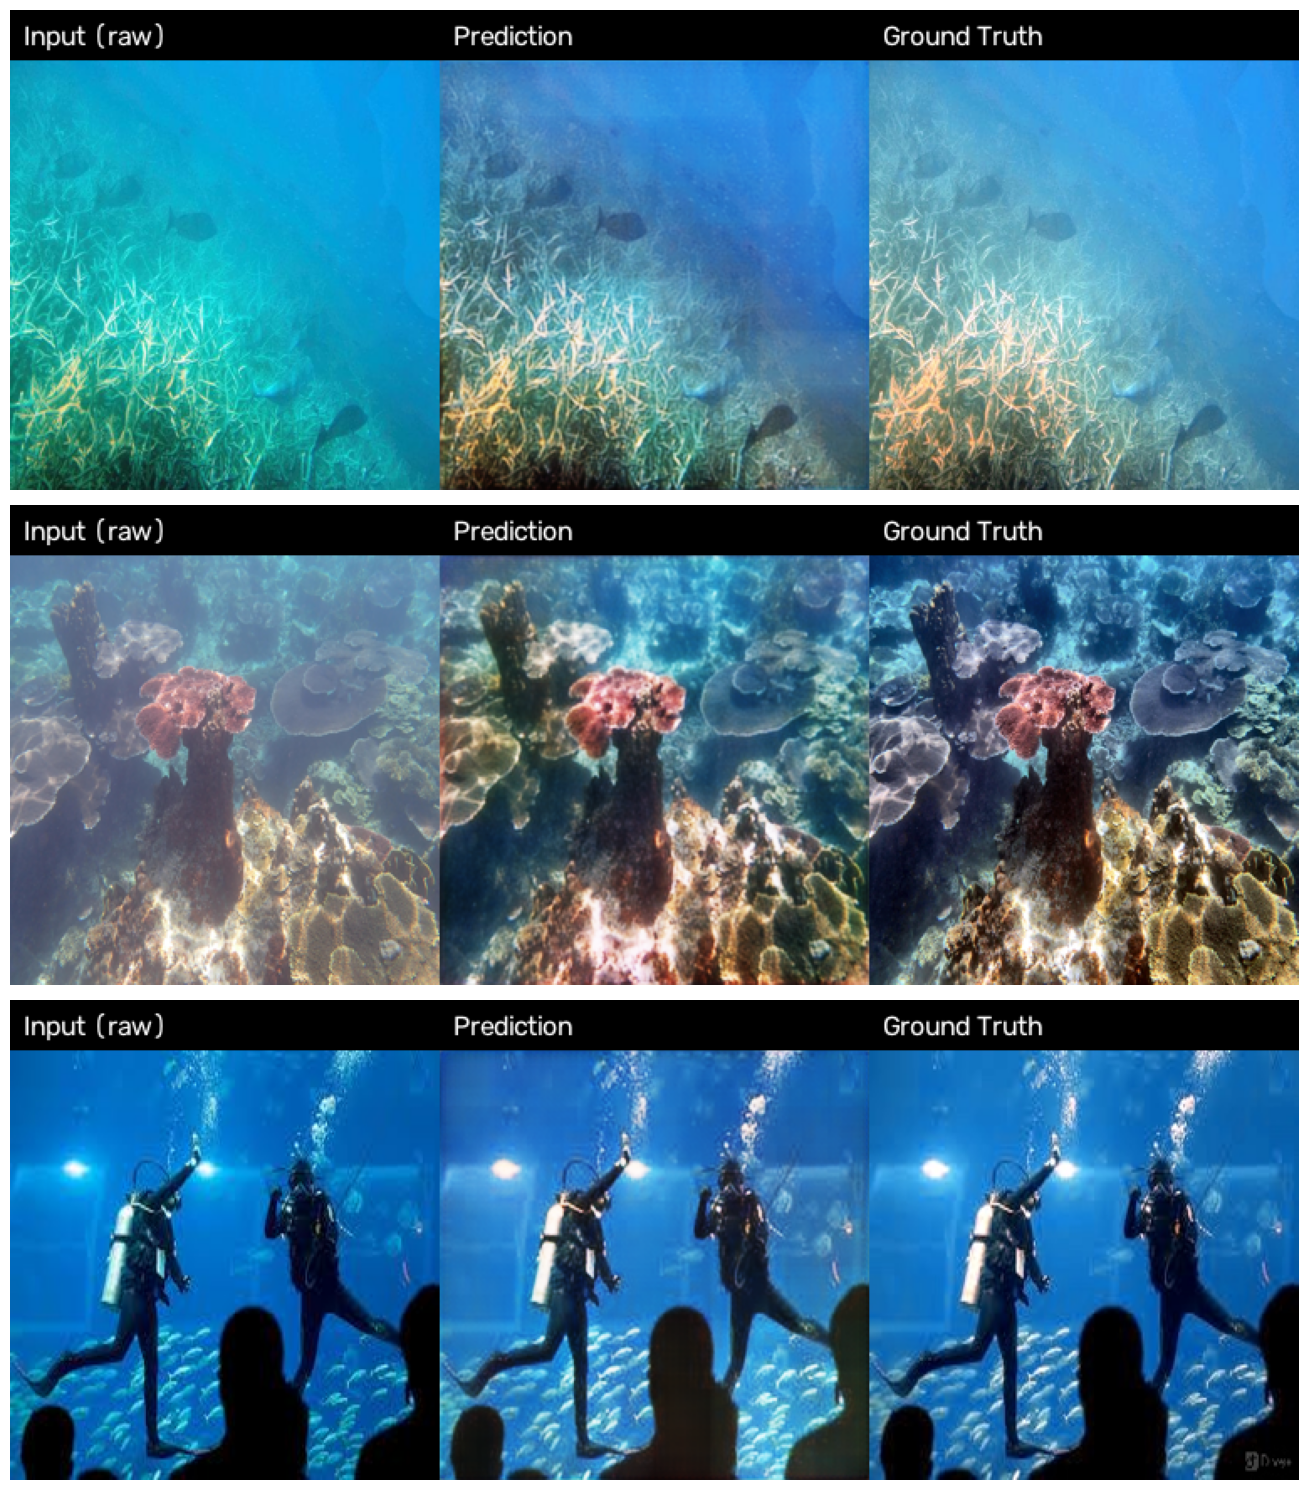

In [13]:
def put_title(image, title):
    """Add a black title bar ABOVE the image (the old version painted over the top 30 px of the image)."""
    bar = np.zeros((30, image.shape[1], 3), dtype=np.uint8)
    cv2.putText(bar, title, (8, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return np.vstack([bar, image])


def save_bgr(path, rgb):
    cv2.imwrite(str(path), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))


@torch.no_grad()
def dehaze_image(image_path, size=IMG_SIZE):
    """Run the model on one image; returns input, prediction and the forward-pass time in ms."""
    generator.eval()
    rgb = load_rgb_resized(image_path, size)            # same bicubic resize as in training
    I = np_to_tensor(rgb).unsqueeze(0).to(DEVICE)

    sync()
    t0 = time.perf_counter()
    pred = enhance(I)
    sync()
    infer_ms = (time.perf_counter() - t0) * 1000.0

    return {"input": rgb, "prediction": tensor_to_uint8(pred), "infer_ms": infer_ms}


def compare_one(raw_path, ref_path, output_dir):
    stem = Path(raw_path).stem
    o = dehaze_image(raw_path)

    gt = load_rgb_resized(ref_path, IMG_SIZE)

    panels = [put_title(o["input"], "Input (raw)"), put_title(o["prediction"], "Prediction"), put_title(gt, "Ground Truth")]

    psnr = peak_signal_noise_ratio(gt, o["prediction"], data_range=255)
    # same SSIM definition as the training code (Gaussian window, sigma=1.5)
    ssim = structural_similarity(gt, o["prediction"], channel_axis=2, data_range=255,
                                 gaussian_weights=True, sigma=1.5, use_sample_covariance=False)
    uiqm = compute_uiqm(o["prediction"])
    print(f"{stem}: PSNR={psnr:.2f} SSIM={ssim:.4f} UIQM(pred)={uiqm:.3f} inference={o['infer_ms']:.1f}ms")

    save_bgr(Path(output_dir) / f"{stem}_input.png", o["input"])
    save_bgr(Path(output_dir) / f"{stem}_prediction.png", o["prediction"])
    save_bgr(Path(output_dir) / f"{stem}_ground_truth.png", gt)
    comparison = np.hstack(panels)
    save_bgr(Path(output_dir) / f"{stem}_comparison.png", comparison)
    return comparison, {"file": Path(raw_path).name, "psnr": psnr, "ssim": ssim, "uiqm": uiqm, "infer_ms": o["infer_ms"]}


N_COMPARE = 5   # number of test images

results = [compare_one(r, g, OUTPUT_DIR) for r, g in test_pairs[:N_COMPARE]]
comparisons = [c for c, _ in results]

comparison_csv = os.path.join(LOG_DIR, "comparison_metrics.csv")
with open(comparison_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["file", "psnr", "ssim", "uiqm", "infer_ms"])
    writer.writeheader()
    writer.writerows(m for _, m in results)
print(f"Saved outputs to: {OUTPUT_DIR}\nPer-image metrics saved to {comparison_csv}")

# Display first 3 comparisons
show = comparisons[:3]
if show:
    plt.figure(figsize=(18, 5 * len(show)))
    for i, c in enumerate(show):
        plt.subplot(len(show), 1, i + 1)
        plt.imshow(c)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
